# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# README 

In [2]:
# Spécifiez le chemin vers votre fichier .xlsx
fichier = "../data/README.xlsx"

# Charger le fichier Excel dans un DataFrame
df = pd.read_excel(fichier, engine='openpyxl')



In [3]:
df

,File,Description,Start time,End time
0,normal.csv,Acquisition of normal network traffic,2021-04-09 11:30:50,2021-04-09 11:27:57
1,dataset_norm.csv,Acquisition of normal physical measures,2021-04-09 11:30:50,2021-04-09 12:27:57
2,attack_1,First acquisition of network traffic with attacks,2021-04-09 18:23:28,2021-04-09 19:03:47
3,dataset_att_1,First acquisition of physical measures under a...,2021-04-09 18:23:28,2021-04-09 19:03:47
4,attack_2,Second acquisition of network traffic with att...,2021-04-19 15:37:12,2021-04-19 16:12:16
5,dataset_att_2,Second acquisition of physical measures under ...,2021-04-19 15:37:12,2021-04-19 16:12:16
6,attack_3,Third acquisition of network traffic with attacks,2021-04-09 19:42:12,2021-04-09 20:03:05
7,dataset_att_3,Third acquisition of physical measures under a...,2021-04-09 19:42:12,2021-04-09 20:03:05
8,attack_4,Fourth acquisition of network traffic with att...,2022-02-21 14:45:25,2022-02-21 15:13:55
9,dataset_att_4,Fourth acquisition of physical measures under ...,2022-02-21 14:45:25,2022-02-21 15:13:55


In [4]:
df['Description'].unique()

array(['Acquisition of normal network traffic',
       'Acquisition of normal physical measures',
       'First acquisition of network traffic with attacks',
       'First acquisition of physical measures under attack',
       'Second acquisition of network traffic with attacks',
       'Second acquisition of physical measures under attack',
       'Third acquisition of network traffic with attacks',
       'Third acquisition of physical measures under attack',
       'Fourth acquisition of network traffic with attacks',
       'Fourth acquisition of physical measures under attack'],
      dtype=object)

# Normal

In [5]:
# Open attack.cs
df_normal = pd.read_csv('../data/Network datatset/raw_csv/normal.csv', delimiter=',', header=0)

In [6]:
df_normal.shape

(7757289, 16)

In [33]:
df_normal.head()

,Time,mac_s,mac_d,ip_s,ip_d,sport,dport,proto,flags,size,modbus_fn,n_pkt_src,n_pkt_dst,modbus_response,label_n,label
0,2021-04-09 11:30:52.716203,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,61516,502,Modbus,11000,66,Read Holding Registers,0,0,NaN,0,normal
1,2021-04-09 11:30:52.716499,fa:00:bc:90:d7:fa,74:46:a0:bd:a7:1b,84.3.251.103,84.3.251.20,502,61516,Modbus,11000,65,Read Holding Registers Response,0,0,[0],0,normal
2,2021-04-09 11:30:52.717334,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,61515,502,Modbus,11000,66,Read Holding Registers,1,0,NaN,0,normal
3,2021-04-09 11:30:52.717624,e6:3f:ac:c9:a8:8c,74:46:a0:bd:a7:1b,84.3.251.101,84.3.251.20,502,61515,Modbus,11000,65,Read Holding Registers Response,0,1,[0],0,normal
4,2021-04-09 11:30:52.717952,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502,61514,Modbus,11000,64,Read Coils Response,0,2,[0],0,normal


In [34]:
df_normal['label'].value_counts()

label
normal    7757289
Name: count, dtype: int64

In [35]:
df_normal['label_n'].value_counts()

label_n
0    7757289
Name: count, dtype: int64

In [38]:
# Comptage des valeurs manquantes
missing_values = df_normal.isnull().sum()

# Affichage des résultats
print("Nombre de valeurs manquantes par colonne :")
print(missing_values)

Nombre de valeurs manquantes par colonne :
Time                     0
mac_s                    0
mac_d                    0
ip_s                     0
ip_d                     0
sport                    0
dport                    0
proto                    0
flags                    0
size                     0
modbus_fn           210243
n_pkt_src                0
n_pkt_dst                0
modbus_response    3983640
label_n                  0
label                    0
dtype: int64


In [39]:
def afficher_value_counts_par_colonne(df, include_na=False):
    for col in df.columns:
        print(f"Valeurs uniques pour la colonne '{col}':")
        if include_na:
            counts = df[col].value_counts(dropna=False)
        else:
            counts = df[col].value_counts()
        print(counts)
        print("-" * 50)

In [42]:
afficher_value_counts_par_colonne(df_normal, include_na=True)

Valeurs uniques pour la colonne 'Time':
Time
2021-04-09 11:33:54.044259    4
2021-04-09 12:01:34.653282    4
2021-04-09 11:31:04.606910    4
2021-04-09 12:01:34.542120    4
2021-04-09 12:01:34.422165    4
                             ..
2021-04-09 11:50:39.406293    1
2021-04-09 11:50:39.406145    1
2021-04-09 11:50:39.405319    1
2021-04-09 11:50:39.405318    1
2021-04-09 12:27:56.049946    1
Name: count, Length: 7128712, dtype: int64
--------------------------------------------------
Valeurs uniques pour la colonne 'mac_s':
mac_s
74:46:a0:bd:a7:1b    3761585
e6:3f:ac:c9:a8:8c    1200522
0a:fe:ec:47:74:fb    1185461
fa:00:bc:90:d7:fa    1176141
00:80:f4:03:fb:12     391958
fe:bb:16:7b:c3:27      20818
4a:35:83:e0:3d:a4      20804
Name: count, dtype: int64
--------------------------------------------------
Valeurs uniques pour la colonne 'mac_d':
mac_d
74:46:a0:bd:a7:1b    3761591
e6:3f:ac:c9:a8:8c    1204552
0a:fe:ec:47:74:fb    1192475
fa:00:bc:90:d7:fa    1175901
00:80:f4:03:fb:12  

# Info sur normal.csv

Fichier de 7 757 289 lignes

Acquisition of normal network traffic

Que des label = 'normal' et 'label_n' = 0

Pas de doublons, les valeurs manquantes sont uniquement dans les colonnes 'modbus_fn' (210 243) et 'modbus_response' (3 983 640)

# Attack

In [43]:
# Open attack.cs
df_attack = pd.read_csv('../data/Network datatset/raw_csv/attack_1.csv', delimiter=',', header=0)

In [44]:
df_attack.shape

(5527409, 16)

In [4]:
df_attack = df_attack.drop_duplicates()

In [5]:
print(df_attack.shape)
print(df_attack.columns)

(5131109, 16)
Index(['Time', 'mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'proto',
       'flags', 'size', 'modbus_fn', 'modbus_response', 'n_pkt_src',
       'n_pkt_dst', 'label_n', 'label'],
      dtype='object')


In [6]:
# Change the name of the columns by removing the spaces
df_attack.columns = df_attack.columns.str.replace(' ', '')

In [7]:
print("Number of rows before droping: ", len(df_attack))
column_NaN = ['Time','mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'flags', 'proto', 'size', 'n_pkt_src', 'n_pkt_dst', 'label']
df_attack = df_attack.dropna(subset=column_NaN)
print("Number of rows after droping: ", len(df_attack))

Number of rows before droping:  5131109
Number of rows after droping:  4350185


In [8]:
def get_columns_info(column_name):
    print('Column name: ', column_name)
    print('Number of unique values in attack: ', df_attack[column_name].nunique())
    print('Number of missing values in attack: ', df_attack[column_name].isnull().sum())
    print('Number of values in attack: ', df_attack[column_name].count())
    print('Values in attack: ', df_attack[column_name].unique())
    print('Values count: ', df_attack[column_name].value_counts())

# Début Rapport d'analyse

problème avec ces colonne : 'ip_s', 'ip_d', 'sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst', 'modbus_fn', 'modbus_response'
raison : missing some values

problème avec modbus_fn, lot of missing value (153121 for attack1), useless column ? Même chose avec modbus_response : Colonne lié au proto modbus et donc pas toute les colonne

La colonne proto contient les protocoles ARP ICMP Modbus TCP pour attack mais seulement Modbus et TCP pour le cas normal

Problème de typage : 'sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst'

Certaine dates sont partagé pour plusieurs entrées (ex : 2021-04-09 18:42:46.997219 a 4 entrés)

Le s dans ip_s, sport est pour source et le d pour destination

Il y a des cas noté normaux dans les csv attack, besoin du csv normal ?

different types d'attaques : 

 - ['normal' 'anomaly' 'MITM' 'physical fault'] pour attack_1
 - ['normal' 'physical fault' 'anomaly' 'DoS' 'MITM'] pour attack_3
 - ['normal' 'scan' 'DoS' 'physical fault' 'MITM'] pour attack_4 et attack_2


In [9]:
get_columns_info('label_n')
get_columns_info('label')

Column name:  label_n
Number of unique values in attack:  2
Number of missing values in attack:  0
Number of values in attack:  4350185
Values in attack:  [0 1]
Values count:  label_n
0    2844877
1    1505308
Name: count, dtype: int64
Column name:  label
Number of unique values in attack:  5
Number of missing values in attack:  0
Number of values in attack:  4350185
Values in attack:  ['normal' 'scan' 'DoS' 'physical fault' 'MITM']
Values count:  label
normal            2844877
DoS                732749
MITM               471241
physical fault     301287
scan                   31
Name: count, dtype: int64


In [10]:
# Conversion des types de données
column_type = ['sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst']
for column in column_type:
    df_attack[column] = df_attack[column].astype('int64')

# On retire les brackets [ ] et on convertit en float64, puis on remplace les NaN par -1 et on convertit en int64

df_attack['modbus_response'] = df_attack['modbus_response'].str.replace('[', '', regex=False).str.replace(']', '', regex=False)
df_attack['modbus_response'] = pd.to_numeric(df_attack['modbus_response'], errors='coerce').fillna(-1).astype('int64')

In [11]:
df_attack['Time'] = pd.to_datetime(df_attack['Time'], errors='coerce')

In [12]:
# Conversion en catégories des colonnes proto, flags, label et modbus_fn
df_attack['proto'] = df_attack['proto'].astype('category')
df_attack['flags'] = df_attack['flags'].astype('category')
df_attack['label'] = df_attack['label'].astype('category')
df_attack['modbus_fn'] = df_attack['modbus_fn'].astype('category')

In [18]:
# Save
df_attack.to_csv('../results/cleaned/Network datatset/attack_4_cleaned.csv', index=False)

In [14]:
df_attack.shape

(4350185, 16)

# Test part from here, will be move to a different file

In [15]:
# Analyse exploratoire des données (EDA)
print("Aperçu des données nettoyées :\n", df_attack.head())
print("\nDescription statistique :\n", df_attack.describe(include='all'))

Aperçu des données nettoyées :
                         Time              mac_s              mac_d  \
0 2022-02-21 14:45:25.454111  74:46:a0:bd:a7:1b  e6:3f:ac:c9:a8:8c   
1 2022-02-21 14:45:25.454114  74:46:a0:bd:a7:1b  fa:00:bc:90:d7:fa   
2 2022-02-21 14:45:25.454142  74:46:a0:bd:a7:1b  0a:fe:ec:47:74:fb   
3 2022-02-21 14:45:25.454260  00:80:f4:03:fb:12  74:46:a0:bd:a7:1b   
4 2022-02-21 14:45:25.454365  e6:3f:ac:c9:a8:8c  74:46:a0:bd:a7:1b   

           ip_s          ip_d  sport  dport   proto  flags  size  \
0   84.3.251.20  84.3.251.101  60614    502  Modbus  11000    66   
1   84.3.251.20  84.3.251.103  60616    502  Modbus  11000    66   
2   84.3.251.20  84.3.251.102  60615    502  Modbus  11000    66   
3   84.3.251.18   84.3.251.20    502  60523     TCP  11000   109   
4  84.3.251.101   84.3.251.20    502  60614  Modbus  11000    65   

                         modbus_fn  modbus_response  n_pkt_src  n_pkt_dst  \
0           Read Holding Registers               -1          

In [20]:
# KNN algorithm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
# Load the cleaned dataframes

df_attack = pd.read_csv('../results/cleaned/Network datatset/attack_4_cleaned.csv', delimiter=',', header=0)

In [22]:
df_attack.columns

Index(['Time', 'mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'proto',
       'flags', 'size', 'modbus_fn', 'modbus_response', 'n_pkt_src',
       'n_pkt_dst', 'label_n', 'label'],
      dtype='object')

In [23]:
import matplotlib.pyplot as plt

# Subset of normal and attack dataframes
df_label1 = df_attack[df_attack['label_n'] == 1]
df_label0 = df_attack[df_attack['label_n'] == 0]

In [24]:
proto1 = df_label1['proto'].value_counts(normalize=True)
print(proto1)

proto0 = df_label0['proto'].value_counts(normalize=True)
print(proto0)

mac_s1 = df_label1['mac_s'].value_counts(normalize=True)
print(mac_s1)

mac_s0 = df_label0['mac_s'].value_counts(normalize=True)
print(mac_s0)

mac_d1 = df_label1['mac_d'].value_counts(normalize=True)
print(mac_d1)

mac_d0 = df_label0['mac_d'].value_counts(normalize=True)
print(mac_d0)

ip_s1 = df_label1['ip_s'].value_counts(normalize=True)
print(ip_s1)

ip_s0 = df_label0['ip_s'].value_counts(normalize=True)
print(ip_s0)

# Rien de spécial entre attack et normal

proto
ICMP      0.437653
Modbus    0.398359
TCP       0.163824
ARP       0.000164
Name: proportion, dtype: float64
proto
Modbus    0.950461
TCP       0.049539
Name: proportion, dtype: float64
mac_s
00:0c:29:47:8c:0e    0.580328
74:46:a0:bd:a7:1b    0.203076
e6:3f:ac:c9:a8:8c    0.063811
0a:fe:ec:47:74:fb    0.063060
fa:00:bc:90:d7:fa    0.062517
00:80:f4:03:fb:12    0.025319
fe:bb:16:7b:c3:27    0.000950
4a:35:83:e0:3d:a4    0.000940
Name: proportion, dtype: float64
mac_s
74:46:a0:bd:a7:1b    0.484809
e6:3f:ac:c9:a8:8c    0.152457
0a:fe:ec:47:74:fb    0.149904
fa:00:bc:90:d7:fa    0.148591
00:80:f4:03:fb:12    0.058928
4a:35:83:e0:3d:a4    0.002656
fe:bb:16:7b:c3:27    0.002655
Name: proportion, dtype: float64
mac_d
00:80:f4:03:fb:12    0.601792
74:46:a0:bd:a7:1b    0.206308
e6:3f:ac:c9:a8:8c    0.063951
0a:fe:ec:47:74:fb    0.063258
fa:00:bc:90:d7:fa    0.062495
fe:bb:16:7b:c3:27    0.000711
4a:35:83:e0:3d:a4    0.000709
00:0c:29:47:8c:0e    0.000655
ff:ff:ff:ff:ff:ff    0.000120
Name

n_pkt_src
97.0    0.129035
90.0    0.094341
95.0    0.063114
94.0    0.059269
14.0    0.056140
96.0    0.052223
50.0    0.047262
15.0    0.040058
49.0    0.030980
13.0    0.028417
Name: proportion, dtype: float64


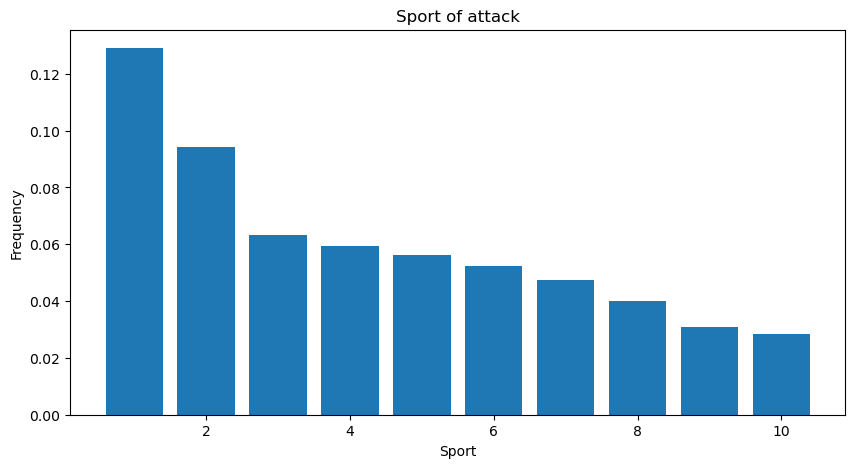

In [25]:
# Plot first 10 sport of attack
sport1 = df_label1['n_pkt_src'].value_counts(normalize=True).head(10)
print(sport1)
# Change index of sport1 to 1 to 5
sport1.index = range(1, 11)
plt.figure(figsize=(10, 5))
plt.bar(sport1.index, sport1.values)
plt.title('Sport of attack')
plt.xlabel('Sport')
plt.ylabel('Frequency')
plt.show()


n_pkt_src
14.0    0.199272
50.0    0.165029
15.0    0.134981
49.0    0.106281
51.0    0.064781
13.0    0.036264
48.0    0.031812
44.0    0.026758
45.0    0.020228
43.0    0.018352
Name: proportion, dtype: float64


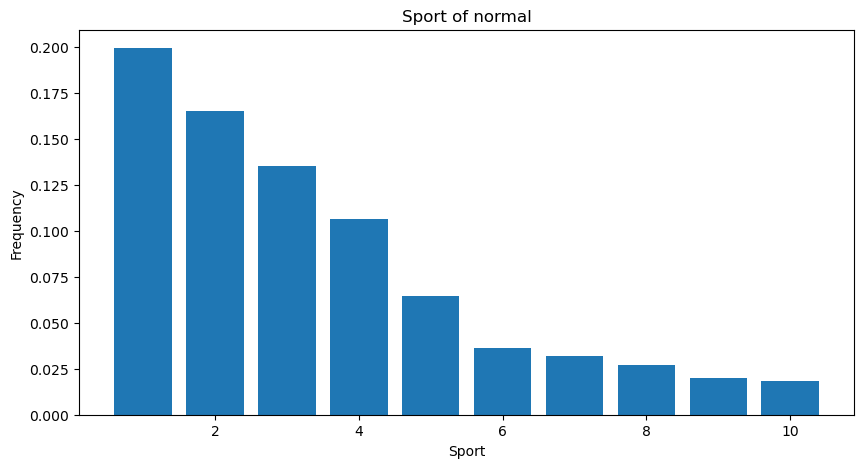

In [26]:
# Plot first 10 sport of attack
sport1 = df_label0['n_pkt_src'].value_counts(normalize=True).head(10)
print(sport1)
# Change index of sport1 to 1 to 5
sport1.index = range(1, 11)
plt.figure(figsize=(10, 5))
plt.bar(sport1.index, sport1.values)
plt.title('Sport of normal')
plt.xlabel('Sport')
plt.ylabel('Frequency')
plt.show()

In [27]:
# Find the range of Date : '2021-04-19 15:37:19.989214' to '2021-04-19 16:12:14.167723'
df_attack.head(30)

,Time,mac_s,mac_d,ip_s,ip_d,sport,dport,proto,flags,size,modbus_fn,modbus_response,n_pkt_src,n_pkt_dst,label_n,label
0,2022-02-21 14:45:25.454111,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,60614.0,502.0,Modbus,11000.0,66,Read Holding Registers,NaN,0.0,0.0,0,normal
1,2022-02-21 14:45:25.454114,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,60616.0,502.0,Modbus,11000.0,66,Read Holding Registers,NaN,1.0,0.0,0,normal
2,2022-02-21 14:45:25.454142,74:46:a0:bd:a7:1b,0a:fe:ec:47:74:fb,84.3.251.20,84.3.251.102,60615.0,502.0,Modbus,11000.0,66,Read Holding Registers,NaN,2.0,0.0,0,normal
3,2022-02-21 14:45:25.454260,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502.0,60523.0,TCP,11000.0,109,NaN,NaN,0.0,0.0,0,normal
4,2022-02-21 14:45:25.454365,e6:3f:ac:c9:a8:8c,74:46:a0:bd:a7:1b,84.3.251.101,84.3.251.20,502.0,60614.0,Modbus,11000.0,65,Read Holding Registers Response,[0],0.0,1.0,0,normal
5,2022-02-21 14:45:25.454415,0a:fe:ec:47:74:fb,74:46:a0:bd:a7:1b,84.3.251.102,84.3.251.20,502.0,60615.0,Modbus,11000.0,65,Read Holding Registers Response,[0],0.0,2.0,0,normal
6,2022-02-21 14:45:25.454416,fa:00:bc:90:d7:fa,74:46:a0:bd:a7:1b,84.3.251.103,84.3.251.20,502.0,60616.0,Modbus,11000.0,65,Read Holding Registers Response,[0],0.0,3.0,0,normal
7,2022-02-21 14:45:25.454720,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502.0,60613.0,Modbus,11000.0,64,Read Coils Response,[0],1.0,4.0,0,normal
8,2022-02-21 14:45:25.457141,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,60614.0,502.0,Modbus,11000.0,66,Read Holding Registers,NaN,3.0,1.0,0,normal
9,2022-02-21 14:45:25.457143,74:46:a0:bd:a7:1b,0a:fe:ec:47:74:fb,84.3.251.20,84.3.251.102,60615.0,502.0,Modbus,11000.0,66,Read Holding Registers,NaN,4.0,1.0,0,normal
